In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup config
current_dir = Path.cwd()
for parent in current_dir.parents:
    if (parent / "config.py").exists():
        sys.path.insert(0, str(parent))
        break

from config import PROCESSED_PATHS, logger

### Carga de datos y validaciones básicas

In [18]:
print("\nCargando CAPA GOLD...")
df = pd.read_parquet('../data/gold/gold_barrios_completo_limpio.parquet')
print(f"Forma: {df.shape}\n")

print("Información general...")
print(f"  Barrios: {len(df)}")
print(f"  Columnas: {len(df.columns)}")
print(f"  Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n[TIPOS DE DATOS]")
print(df.dtypes.value_counts())
print(df.describe())
df.head()


Cargando CAPA GOLD...
Forma: (130, 26)

Información general...
  Barrios: 130
  Columnas: 26
  Memoria: 0.03 MB

[TIPOS DE DATOS]
float64    21
str         3
int64       2
Name: count, dtype: int64
       barrio_id  n_bares_202206  n_bares_202606  velocidad_crecimiento_anual  \
count     130.00          130.00          130.00                       130.00   
mean      110.24           -0.00           -0.00                         0.00   
std        58.89            1.00            1.00                         1.00   
min        11.00           -1.21           -1.18                        -1.26   
25%        62.25           -0.74           -0.75                        -0.42   
50%       109.00           -0.25           -0.28                        -0.15   
75%       156.75            0.46            0.42                         0.22   
max       215.00            4.20            4.08                         8.91   

       aceleracion_crecimiento  tendencia_54m  variabilidad_bares  \
co

,barrio_id,barrio_nombre,n_bares_202206,n_bares_202606,velocidad_crecimiento_anual,aceleracion_crecimiento,tendencia_54m,variabilidad_bares,diversidad_categorias,bares_por_1000hab,poblacion_total,edad_media,pct_extranjeros,tasa_natalidad,indice_diversidad_cultural,pct_menores_30,renta_media_2023,renta_mediana_2023,cambio_renta_2022_2026,categoria_renta,desigualdad_gini,pct_poblacion_renta_baja,distancia_centro,proximidad_estaciones_metro,zona,gentrificara
0,11,Palacio,3.88,3.73,-0.15,0.03,1.26,2.03,0.88,0.00,-0.23,0.61,0.72,-1.79,0.84,-1.45,0.08,-0.26,0.08,Medium,1.94,-0.21,-1.37,0.42,Sur-Oeste,0
1,12,Embajadores,3.32,2.99,-0.42,0.79,-0.14,0.59,0.49,0.00,1.34,-0.52,1.97,-1.48,1.70,-0.98,0.08,-0.26,0.08,Medium,1.94,-0.21,-0.91,0.47,Sur-Oeste,0
2,13,Cortes,2.62,2.64,0.06,-2.91,2.09,1.73,0.49,0.00,-1.06,0.25,1.52,-1.93,1.44,-1.47,0.08,-0.26,0.08,Medium,1.94,-0.21,-1.51,0.37,Sur-Oeste,1
3,14,Justicia,3.12,3.18,0.11,-1.82,2.69,2.83,0.49,0.00,-0.58,0.02,1.38,-1.69,1.35,-1.08,0.08,-0.26,0.08,Medium,1.94,-0.21,-1.47,0.42,Sur-Oeste,1
4,15,Universidad,4.20,4.08,-0.10,0.03,2.28,2.62,0.88,0.00,0.41,-0.13,1.35,-1.79,1.33,-0.99,0.08,-0.26,0.08,Medium,1.94,-0.21,-1.06,0.45,Sur-Oeste,0


### Análisis de target

In [19]:
print("\nTARGET - gentrificara")
target_counts = df['gentrificara'].value_counts()
print(f"  NO (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"  SÍ (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")



TARGET - gentrificara
  NO (0): 98 (75.4%)
  SÍ (1): 32 (24.6%)


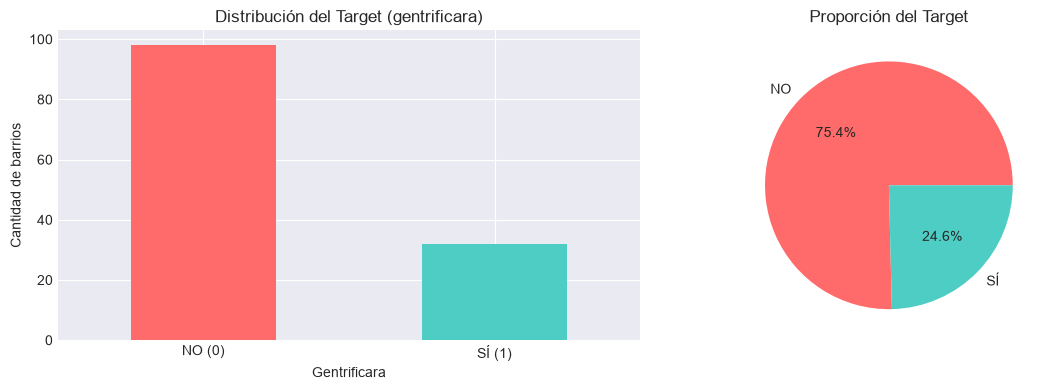

In [22]:
# Crear visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
target_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribución del Target (gentrificara)')
axes[0].set_xlabel('Gentrificara')
axes[0].set_ylabel('Cantidad de barrios')
axes[0].set_xticklabels(['NO (0)', 'SÍ (1)'], rotation=0)

axes[1].pie(target_counts, labels=['NO', 'SÍ'], autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Proporción del Target')

plt.tight_layout()
plt.show()

### Distribución de features hostelería

In [23]:

host_cols = ['n_bares_202206', 'n_bares_202606', 'velocidad_crecimiento_anual', 
             'aceleracion_crecimiento', 'tendencia_54m', 'variabilidad_bares']

for col in host_cols:
    print(f"  {col}:")
    print(f"    Media: {df[col].mean():.3f}, Std: {df[col].std():.3f}")
    print(f"    Min: {df[col].min():.3f}, Max: {df[col].max():.3f}")

  n_bares_202206:
    Media: -0.000, Std: 1.004
    Min: -1.211, Max: 4.202
  n_bares_202606:
    Media: -0.000, Std: 1.004
    Min: -1.183, Max: 4.082
  velocidad_crecimiento_anual:
    Media: 0.000, Std: 1.004
    Min: -1.260, Max: 8.906
  aceleracion_crecimiento:
    Media: 0.000, Std: 1.004
    Min: -2.907, Max: 4.513
  tendencia_54m:
    Media: 0.000, Std: 1.004
    Min: -1.792, Max: 5.042
  variabilidad_bares:
    Media: -0.000, Std: 1.004
    Min: -1.460, Max: 4.522


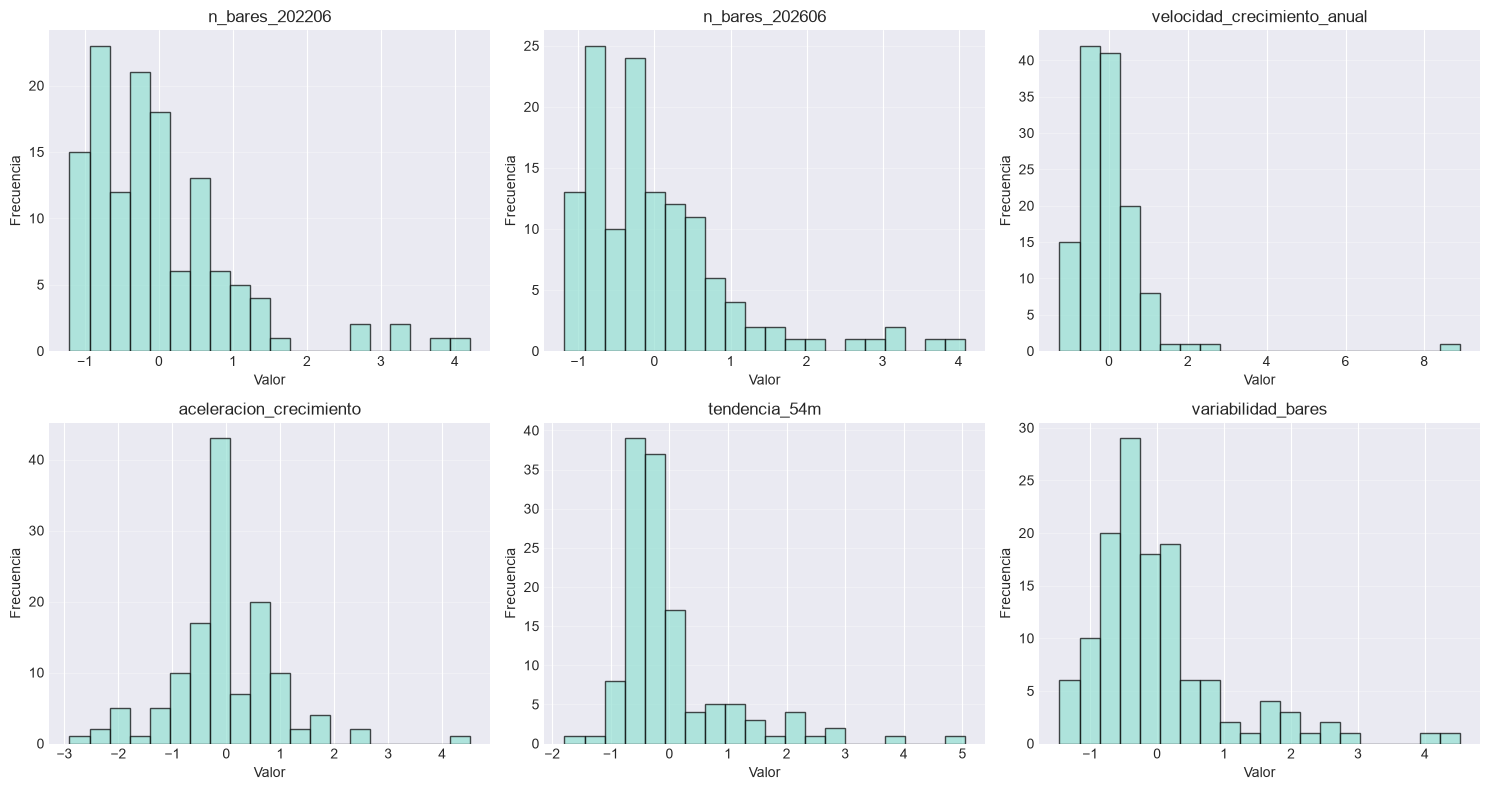

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(host_cols):
    axes[idx].hist(df[col], bins=20, color='#95E1D3', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Distribución de features geográficas

In [26]:
demo_cols = ['poblacion_total', 'edad_media', 'pct_extranjeros', 
             'tasa_natalidad', 'indice_diversidad_cultural', 'pct_menores_30']

for col in demo_cols:
    print(f"  {col}:")
    print(f"    Media: {df[col].mean():.3f}, Std: {df[col].std():.3f}")

  poblacion_total:
    Media: -0.000, Std: 1.004
  edad_media:
    Media: 0.000, Std: 1.004
  pct_extranjeros:
    Media: -0.000, Std: 1.004
  tasa_natalidad:
    Media: -0.000, Std: 1.004
  indice_diversidad_cultural:
    Media: 0.000, Std: 1.004
  pct_menores_30:
    Media: -0.000, Std: 1.004


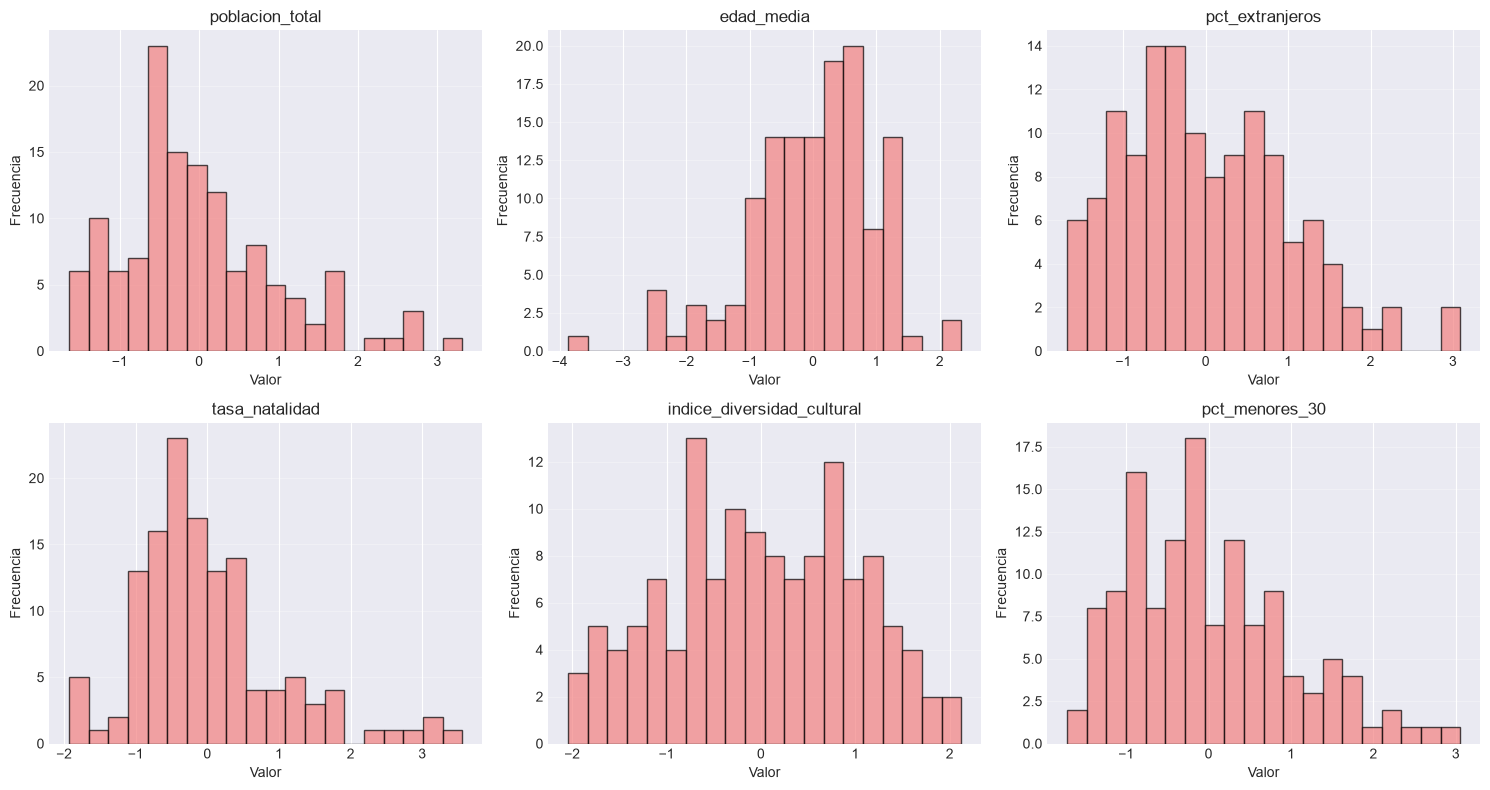

In [27]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(demo_cols):
    axes[idx].hist(df[col], bins=20, color='#F38181', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Distribución de  features económicos

In [28]:
econ_cols = ['renta_media_2023', 'renta_mediana_2023', 'cambio_renta_2022_2026', 
             'desigualdad_gini', 'pct_poblacion_renta_baja']

for col in econ_cols:
    print(f"  {col}:")
    print(f"    Media: {df[col].mean():.3f}, Std: {df[col].std():.3f}")

  renta_media_2023:
    Media: -0.000, Std: 1.004
  renta_mediana_2023:
    Media: -0.000, Std: 1.004
  cambio_renta_2022_2026:
    Media: 0.000, Std: 1.004
  desigualdad_gini:
    Media: 0.000, Std: 1.004
  pct_poblacion_renta_baja:
    Media: 0.000, Std: 1.004


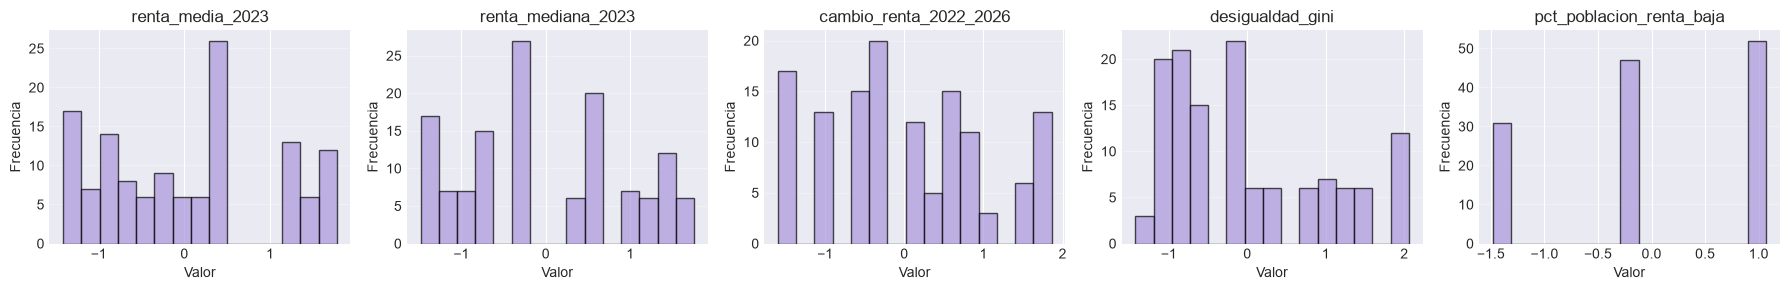

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))

for idx, col in enumerate(econ_cols):
    axes[idx].hist(df[col], bins=15, color='#AA96DA', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Features Geográficas

In [30]:

geo_cols = ['distancia_centro', 'proximidad_estaciones_metro']

for col in geo_cols:
    print(f"  {col}:")
    print(f"    Media: {df[col].mean():.3f}, Std: {df[col].std():.3f}")

print(f"\n[CATEGORÍAS]")
print(f"  categoria_renta:")
print(df['categoria_renta'].value_counts())
print(f"\n  zona:")
print(df['zona'].value_counts())

  distancia_centro:
    Media: 0.000, Std: 1.004
  proximidad_estaciones_metro:
    Media: 0.000, Std: 1.004

[CATEGORÍAS]
  categoria_renta:
categoria_renta
Low       52
Medium    47
High      31
Name: count, dtype: int64

  zona:
zona
Sur-Oeste    130
Name: count, dtype: int64


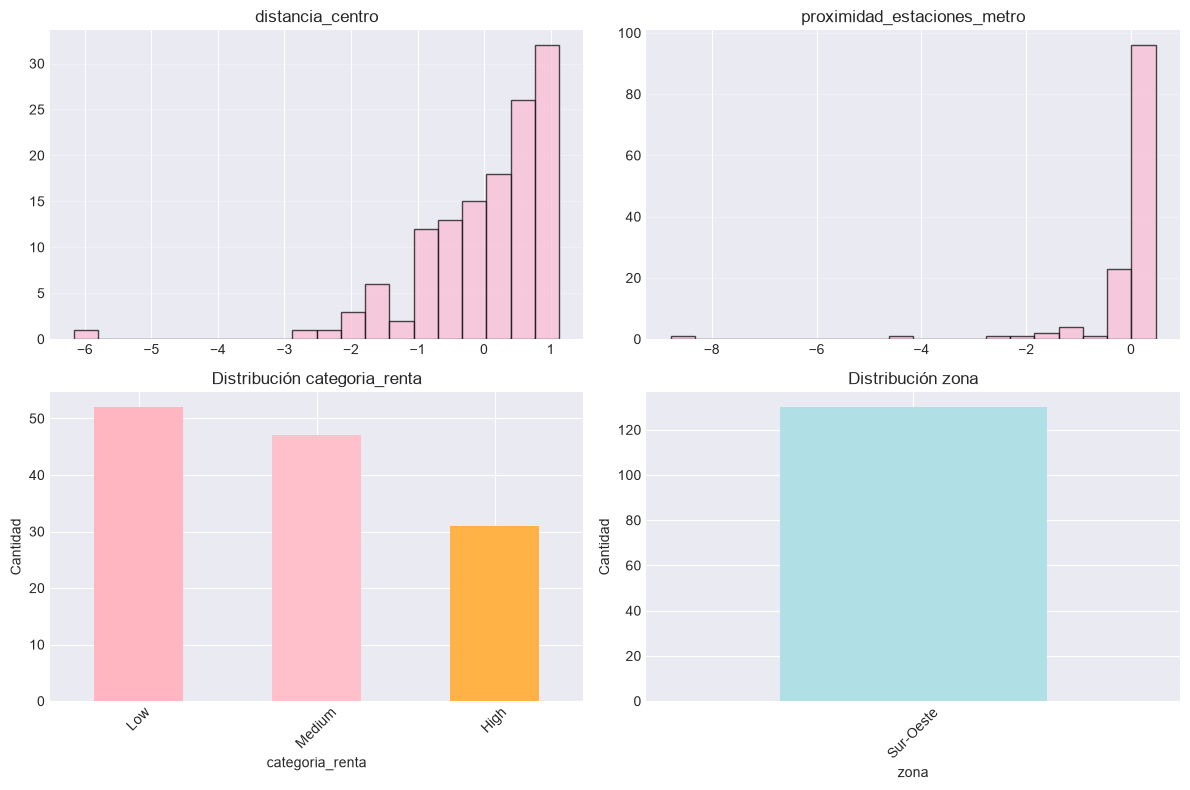

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Geográficos
axes[0, 0].hist(df['distancia_centro'], bins=20, color='#FCBAD3', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('distancia_centro')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].hist(df['proximidad_estaciones_metro'], bins=20, color='#FCBAD3', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('proximidad_estaciones_metro')
axes[0, 1].grid(axis='y', alpha=0.3)

# Categorías
df['categoria_renta'].value_counts().plot(kind='bar', ax=axes[1, 0], color=['#FFB6C1', '#FFC0CB', '#FFB347'])
axes[1, 0].set_title('Distribución categoria_renta')
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

df['zona'].value_counts().plot(kind='bar', ax=axes[1, 1], color=['#B0E0E6', '#87CEEB'])
axes[1, 1].set_title('Distribución zona')
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Correlaciones

In [32]:
features_num = df.select_dtypes(include=[np.number]).columns.tolist()
features_num.remove('barrio_id')
features_num.remove('gentrificara')

corr_target = df[features_num + ['gentrificara']].corr()['gentrificara'].sort_values(ascending=False)
print(corr_target.head(15))

gentrificara                   1.00
tendencia_54m                  0.63
variabilidad_bares             0.56
renta_media_2023               0.49
renta_mediana_2023             0.47
desigualdad_gini               0.45
n_bares_202606                 0.40
n_bares_202206                 0.34
cambio_renta_2022_2026         0.32
diversidad_categorias          0.32
velocidad_crecimiento_anual    0.25
proximidad_estaciones_metro    0.16
aceleracion_crecimiento        0.08
edad_media                     0.07
indice_diversidad_cultural    -0.05
Name: gentrificara, dtype: float64


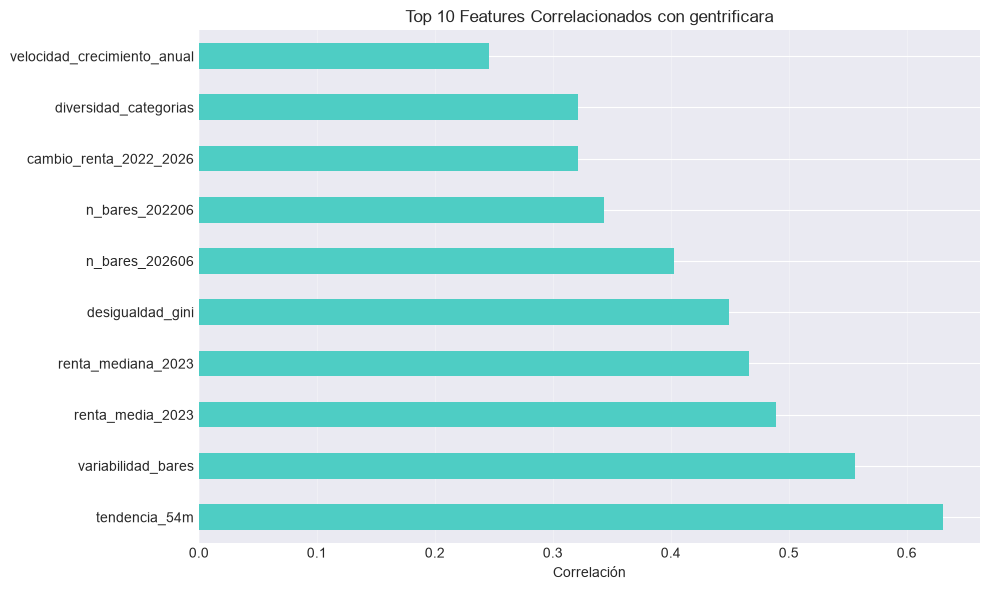

In [33]:
# Visualizar top 10
fig, ax = plt.subplots(figsize=(10, 6))
corr_top = corr_target[1:11]  # Excluir gentrificara
corr_top.plot(kind='barh', ax=ax, color=['#4ECDC4' if x > 0 else '#FF6B6B' for x in corr_top])
ax.set_title('Top 10 Features Correlacionados con gentrificara')
ax.set_xlabel('Correlación')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Matriz de correlaciones completa

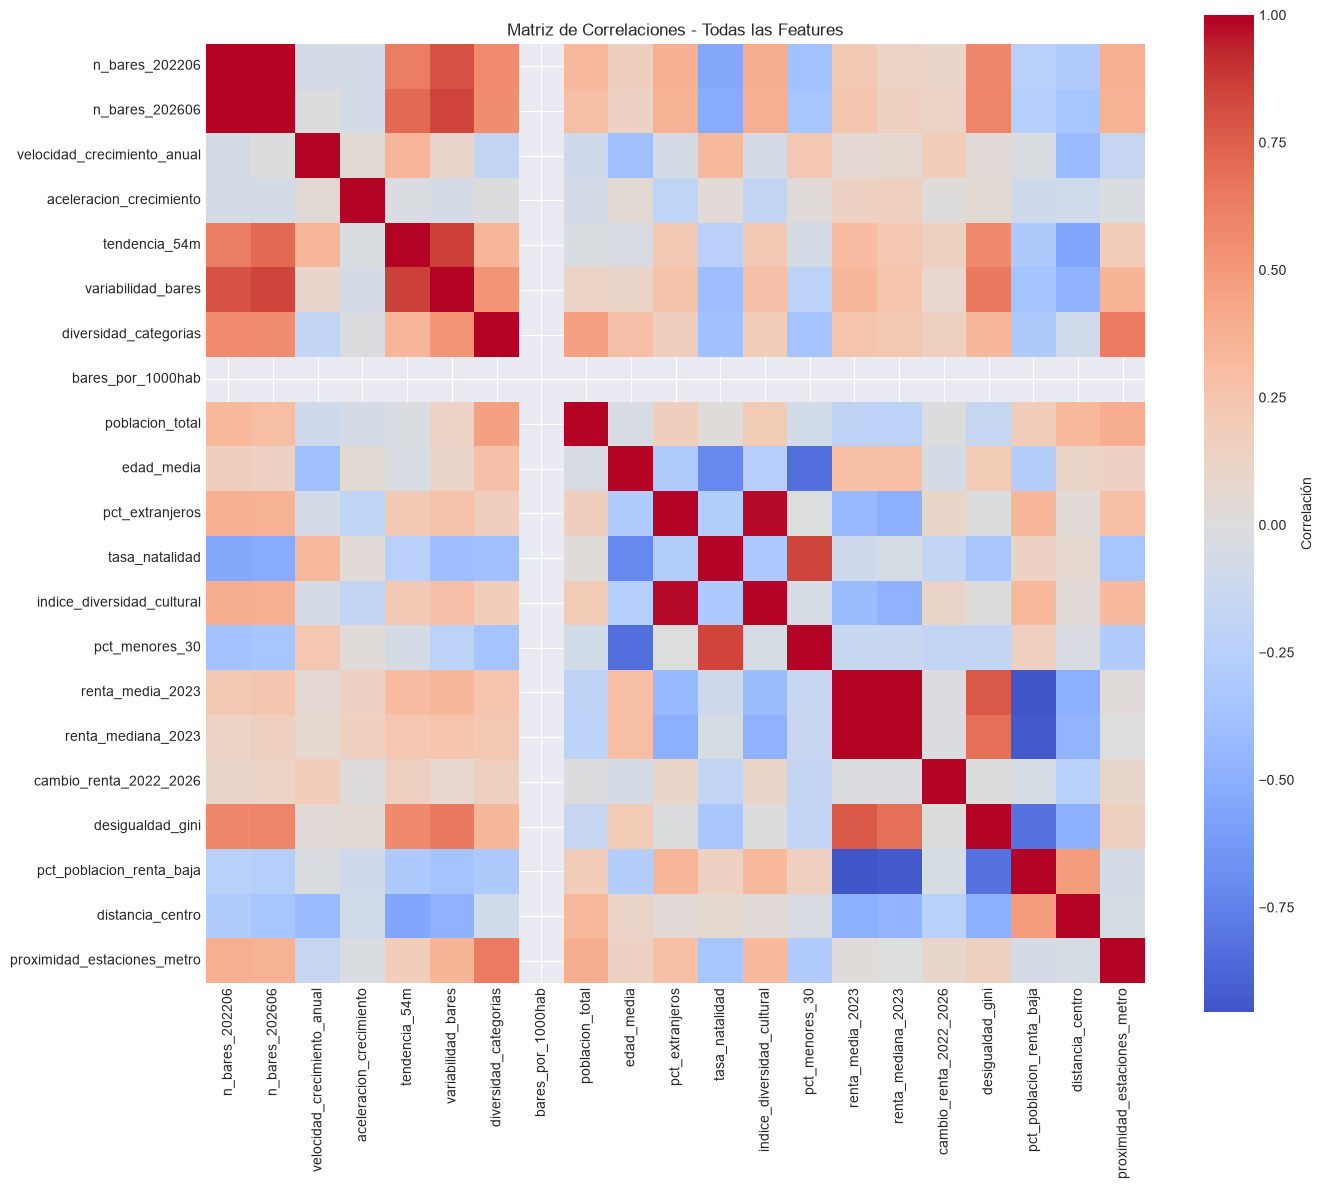

In [34]:
corr_matrix = df[features_num].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlaciones - Todas las Features')

plt.tight_layout()
plt.show()


### Target vs Features claves

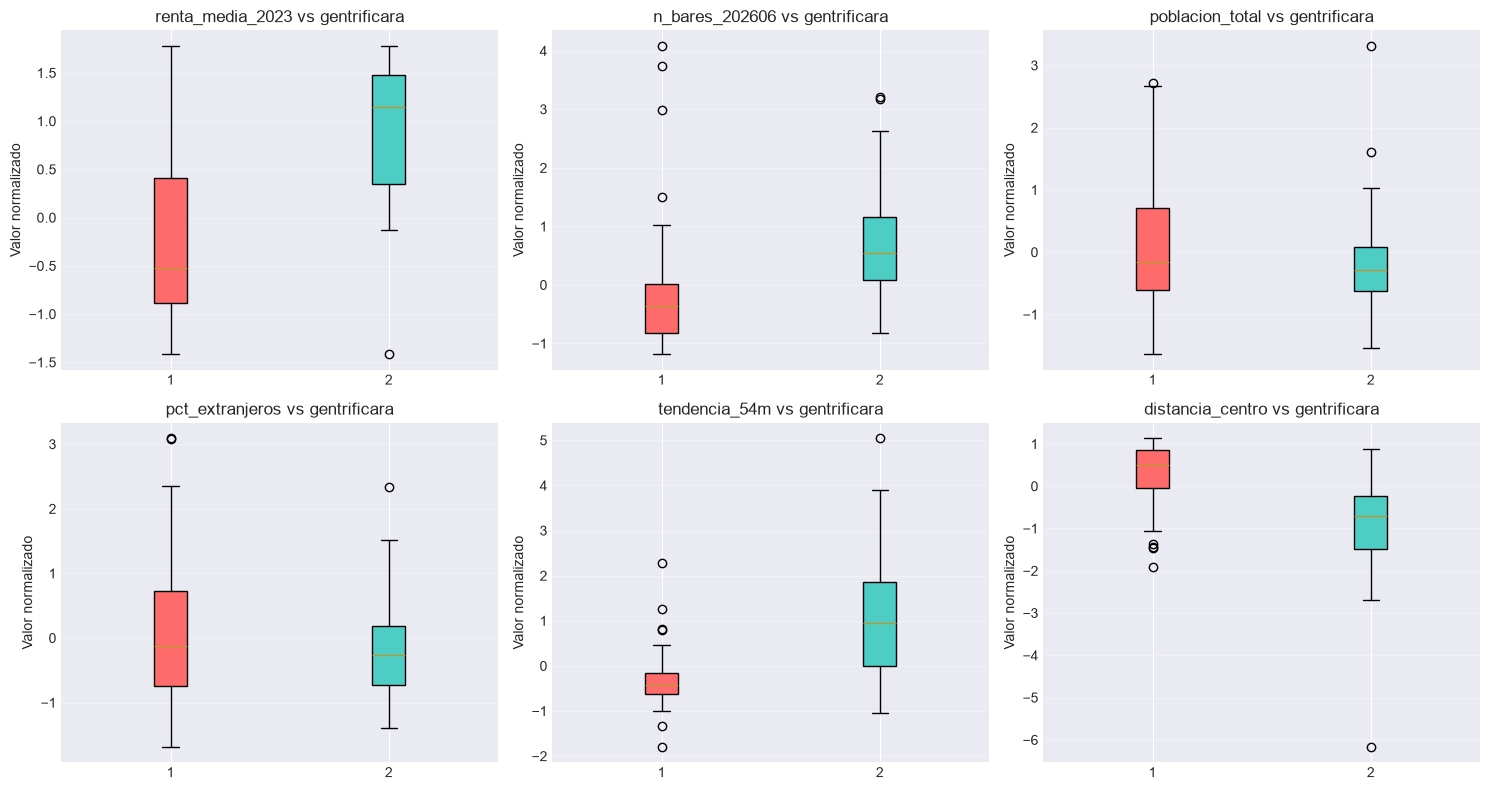

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

key_features = ['renta_media_2023', 'n_bares_202606', 'poblacion_total', 
                'pct_extranjeros', 'tendencia_54m', 'distancia_centro']

for idx, col in enumerate(key_features):
    # Boxplot
    data_no = df[df['gentrificara'] == 0][col]
    data_si = df[df['gentrificara'] == 1][col]
    
    bp = axes[idx].boxplot([data_no, data_si], label=['NO', 'SÍ'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
        patch.set_facecolor(color)
    
    axes[idx].set_title(f'{col} vs gentrificara')
    axes[idx].set_ylabel('Valor normalizado')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
